**Script Description**

Complete script for 5GDHC pre‐processing and candidate group evaluation,
with the ability to select only a few building IDs from external Excel files.

Files:
  - config.xlsx: Contains building configuration (Building ID, Extended Name, 
      Supply Temp Heating, Supply Temp Cooling, Supply Temp DHW).
  - data.xlsx: Contains hourly energy profiles (one sheet per service: 
      "H", "C", "W", "Wrec", "Erec").

For each building, the base load is computed from heating, cooling, and DHW load vectors.
If weighted_base_enabled is True, the base is computed as a weighted sum using the supply temperatures
(from config.xlsx) and the network set point.

Excess heat is computed as the element‐wise sum of the "Wrec" and "Erec" sheets.
At the moment, excess heat is not yet considered for the evaluation of the base load consumption, therefore is not considered in the computation of TS and TSI values.

You may manually specify a list of Building IDs to include in the analysis via the selected_building_ids parameter.
Also, candidate groups are limited to those of size between (N – m) and N.
"""

**Import required libraries**

In [1]:

import os
import csv
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import linregress  # to plto linear regression trendline

from matplotlib.colors import ListedColormap

# Enable inline plotting for Jupyter
%matplotlib inline


**Configuration parameters**

In [2]:
# File paths and Configuration flags

#File paths
config_file = 'configNY.xlsx'
data_file = 'dataNY.xlsx'

# Flags
weighted_base_enabled = False  # Weight energy profiles based on supply temps
network_setpoint = 15.0       # Network set-point temperature (°C)
m = 3  # Candidate group filtering (N-m to N buildings only)

# Manually select building IDs (leave empty to use all)
# I selected all the buildings IDs from 1 to 8 for the BS paper purposes (check config.xlsx file)
selected_building_ids = ["1","2","3","4","5","6","7","8"]

**Reading Configration input file**

In [3]:
df_config = pd.read_excel(config_file)
all_building_ids = df_config['ID'].astype(str).tolist()

# Filter buildings if a subset is specified
if selected_building_ids:
    df_config = df_config[df_config['ID'].astype(str).isin(selected_building_ids)]
    positions = [all_building_ids.index(bid) for bid in selected_building_ids if bid in all_building_ids]
    building_ids = df_config['ID'].astype(str).tolist()
else:
    building_ids = all_building_ids
    positions = list(range(len(building_ids)))

num_buildings = len(building_ids)
print(f"Number of buildings selected: {num_buildings}")

# Create a dictionary of supply temperatures (per building) from config.xlsx.
supply_temps = {}
for _, row in df_config.iterrows():
    bid = str(row['ID'])
    supply_temps[bid] = {
        'heating': row['tempHeating'],
        'cooling': row['tempCooling'],
        'dhw': row['tempDhw']
    }

Number of buildings selected: 8


**Reading Data input file**

In [4]:
sheets_required = ['H', 'C', 'W', 'Wrec', 'Erec']
data_sheets = {}
xls = pd.ExcelFile(data_file)
for sheet in sheets_required:
    df = pd.read_excel(xls, sheet_name=sheet, header=None).dropna(how='all')
    if df.shape[0] != 8760:
        raise ValueError(f"Sheet '{sheet}' has {df.shape[0]} rows; expected 8760.")
    data_sheets[sheet] = df

T = 8760  # Time series length

**Create Buildings Dictionary**

In [5]:
buildings = {}
for pos, bid in zip(positions, building_ids):
    heating = np.array(data_sheets['H'].iloc[:, pos])
    cooling = -np.abs(np.array(data_sheets['C'].iloc[:, pos]))  # Cooling must be NEGATIVE
    dhw     = np.array(data_sheets['W'].iloc[:, pos])
    wrec    = -np.abs(np.array(data_sheets['Wrec'].iloc[:, pos]))  # Excess heat from DHW must be NEGATIVE
    erec    = -np.abs(np.array(data_sheets['Erec'].iloc[:, pos]))  # Excess heat must be NEGATIVE
    excess = wrec + erec

       # Compute the base vector. Base vector is the (weighted) sum of heating, cooling and dhw used for TS evaluation
    if weighted_base_enabled:
        temps = supply_temps[bid]
        diff_heating = abs(network_setpoint - temps['heating'])
        diff_cooling = abs(network_setpoint - temps['cooling'])
        diff_dhw     = abs(network_setpoint - temps['dhw'])
        total_diff = diff_heating + diff_cooling + diff_dhw
        weight_heating = diff_heating / total_diff
        weight_cooling = diff_cooling / total_diff
        weight_dhw = diff_dhw / total_diff
        base = weight_heating * heating + weight_cooling * cooling + weight_dhw * dhw
    else:
        base = heating + cooling + dhw

    buildings[bid] = {
        'heating': heating, 
        'cooling': cooling,
        'dhw': dhw,
        'base': base,
        'excess': excess,
        'supply_temps': supply_temps[bid]
    }


**Extra check: Plotting specific buildings energy profiles**

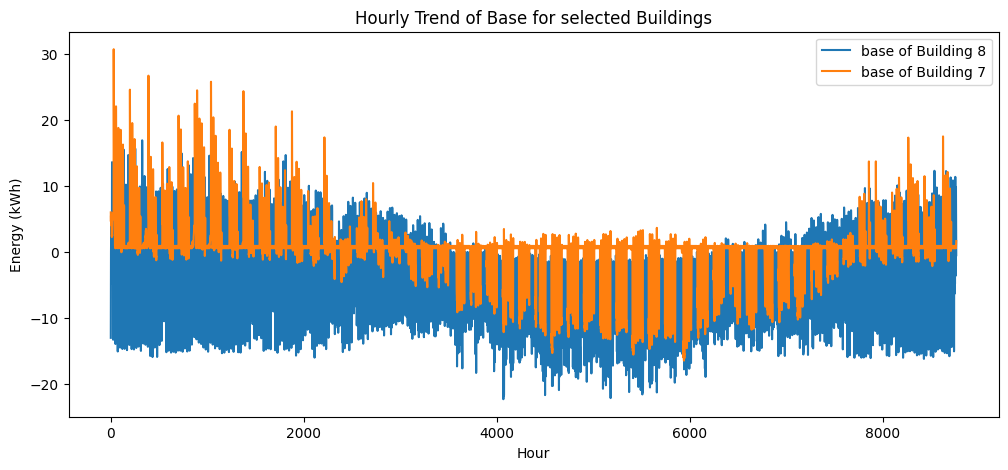

In [6]:
building_to_plot = "8"  # Example: Change to desired building ID
building_to_plot2 = "7"  # Example: Change to desired building ID
variable_to_plot = "base"  # Options: 'heating', 'cooling', 'dhw', 'excess', 'base'
variable_to_plot2 = "base"  # Options: 'heating', 'cooling', 'dhw', 'excess', 'base'

if building_to_plot in buildings and variable_to_plot in buildings[building_to_plot]:
    plt.figure(figsize=(12, 5))
    plt.plot(buildings[building_to_plot][variable_to_plot], label=f"{variable_to_plot} of Building {building_to_plot}")
    plt.plot(buildings[building_to_plot2][variable_to_plot2], label=f"{variable_to_plot2} of Building {building_to_plot2}")
    plt.xlabel("Hour")

    plt.ylabel("Energy (kWh)")
    plt.title(f"Hourly Trend of {variable_to_plot.capitalize()} for selected Buildings")
    plt.legend()
    plt.show()
else:
    print(f"Error: Invalid building ID or variable selection.")

**Energy need signature coupling based on Euler Norm**

In [7]:
# Each building's energy_need_signature is its base profile.
energy_need_signature = {bid: buildings[bid]['base'] for bid in buildings}

# Only evaluate candidate groups of size between (N - m) and N.
min_group_size = num_buildings - m
max_group_size = len(buildings)
print(f"Evaluating candidate groups of size between {min_group_size} and {max_group_size}.")


# Dictionary to store the Eucliden norm (Thermal Synergy - TS) for each candidate combination.
# TSI instead is the relative value of TS, where TS is divided by the total energy need of the combinantion
combination_results = {} # Stores TS for each combination
combination_results_TSI = {}  # Stores TSI for each combination
size_group_ts = {}


# Loop over all candidate combinations.
for r in range(min_group_size, max_group_size + 1):
    ts_values = []
    for combo in itertools.combinations(buildings.keys(), r):
        total_signature = np.zeros(T)
        # Sum the energy_need_signatures for the buildings in the combo.
        for bid in combo:
            total_signature += energy_need_signature[bid]
        # Compute the TS as the Eucliden norm of the total signature.
        TS = np.linalg.norm(total_signature)
        # Compute the sum of absolute values of the total signature.
        abs_sum = np.sum(np.abs(total_signature))
        # Compute TSI as TS divided by the sum of absolute values (handling zero denominator if needed)
        TSI = TS / abs_sum if abs_sum != 0 else np.nan
        
        combination_results[combo] = TS
        combination_results_TSI[combo] = TSI
        print(f"Group {combo}: TS = {TS:.3f}, TSI = {TSI:.3f}")
        
        ts_values.append(TS)
    size_group_ts[r] = np.mean(ts_values)

# Identify the best combination (with lowest TS).
best_combo = min(combination_results, key=combination_results.get)
best_norm = combination_results[best_combo]

print("Total simulated combinations = ", len(combination_results))
print("Best combination is:", best_combo, "with (Thermal Synergy) Euclidean distance from 0:", best_norm)


Evaluating candidate groups of size between 5 and 8.
Group ('1', '2', '3', '4', '5'): TS = 13796.510, TSI = 0.014
Group ('1', '2', '3', '4', '6'): TS = 43908.554, TSI = 0.012
Group ('1', '2', '3', '4', '7'): TS = 10678.815, TSI = 0.015
Group ('1', '2', '3', '4', '8'): TS = 10920.409, TSI = 0.015
Group ('1', '2', '3', '5', '6'): TS = 38129.146, TSI = 0.012
Group ('1', '2', '3', '5', '7'): TS = 10022.120, TSI = 0.014
Group ('1', '2', '3', '5', '8'): TS = 10169.005, TSI = 0.014
Group ('1', '2', '3', '6', '7'): TS = 37716.195, TSI = 0.011
Group ('1', '2', '3', '6', '8'): TS = 38099.327, TSI = 0.011
Group ('1', '2', '3', '7', '8'): TS = 5660.737, TSI = 0.014
Group ('1', '2', '4', '5', '6'): TS = 43732.397, TSI = 0.012
Group ('1', '2', '4', '5', '7'): TS = 12928.208, TSI = 0.015
Group ('1', '2', '4', '5', '8'): TS = 13087.876, TSI = 0.015
Group ('1', '2', '4', '6', '7'): TS = 43440.206, TSI = 0.012
Group ('1', '2', '4', '6', '8'): TS = 43786.836, TSI = 0.012
Group ('1', '2', '4', '7', '8'): 

**Plot 1: results ordered by group size**

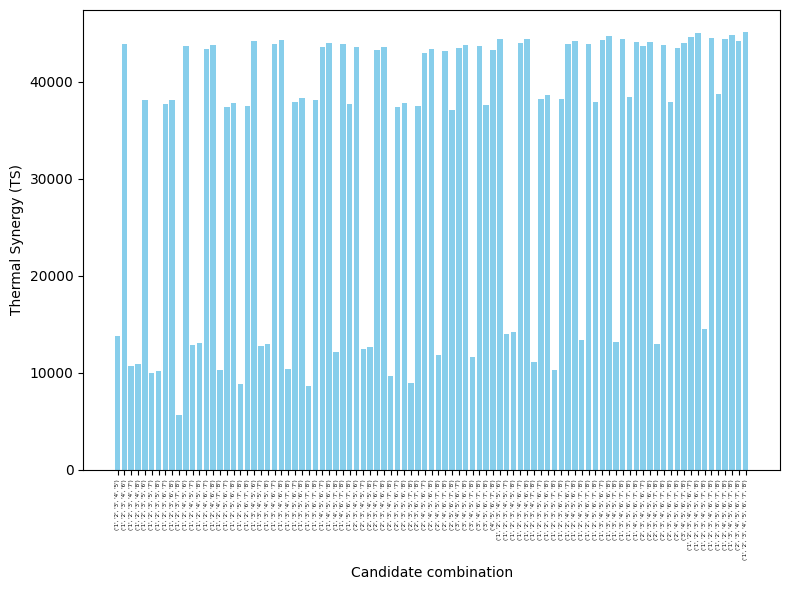

In [8]:
# For plotting, if the number of combinations is large, you may wish to plot only a subset.
# For now, we'll plot all combinations in a bar graph since we only have 8 buildings in the BS paper.
combos = list(combination_results.keys())
ts_values = [combination_results[combo] for combo in combos]

plt.figure(figsize=(8, 6))
plt.bar(range(len(combos)), ts_values, color='skyblue')
plt.xlabel("Candidate combination")
plt.ylabel("Thermal Synergy (TS)")
#plt.title("Evaluation of candidate combinations")
plt.xticks(range(len(combos)), [str(combo) for combo in combos], rotation=90, fontsize=4)
plt.tight_layout()
plt.show()


**Plot 2: results ordered by TS**

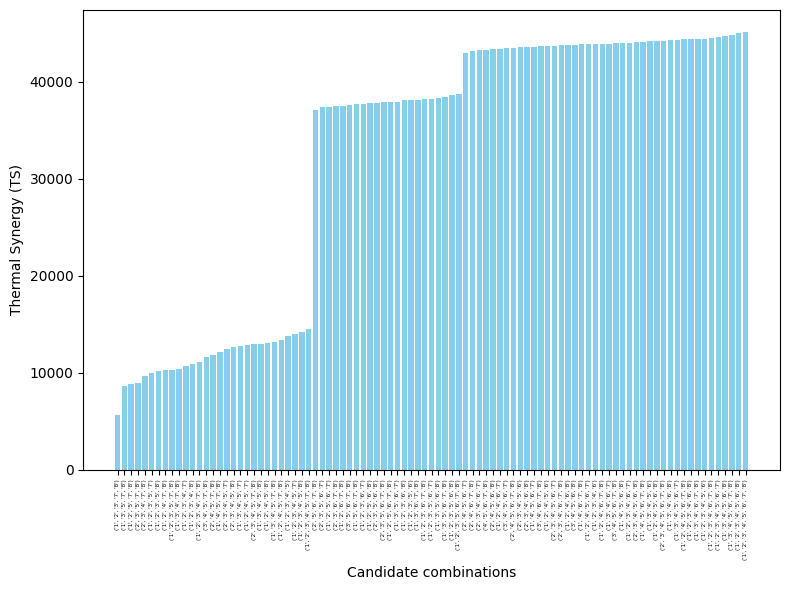

In [9]:
# Sort combinations by increasing standard deviation
sorted_combos = sorted(combination_results.items(), key=lambda x: x[1])
sorted_labels = [str(combo[0]) for combo in sorted_combos]
sorted_values = [combo[1] for combo in sorted_combos]

# Plot ordered bar graph
plt.figure(figsize=(8, 6))
plt.bar(range(len(sorted_labels)), sorted_values, color='skyblue')
plt.xlabel("Candidate combinations")
plt.ylabel("Thermal Synergy (TS)")
#plt.title("Evaluation of candidate combinations (Sorted by Performance)")
plt.xticks(range(len(sorted_labels)), sorted_labels, rotation=90, fontsize=4)
plt.tight_layout()
plt.show()


**Alternative plots 1 and 2: TSI instad of TS**

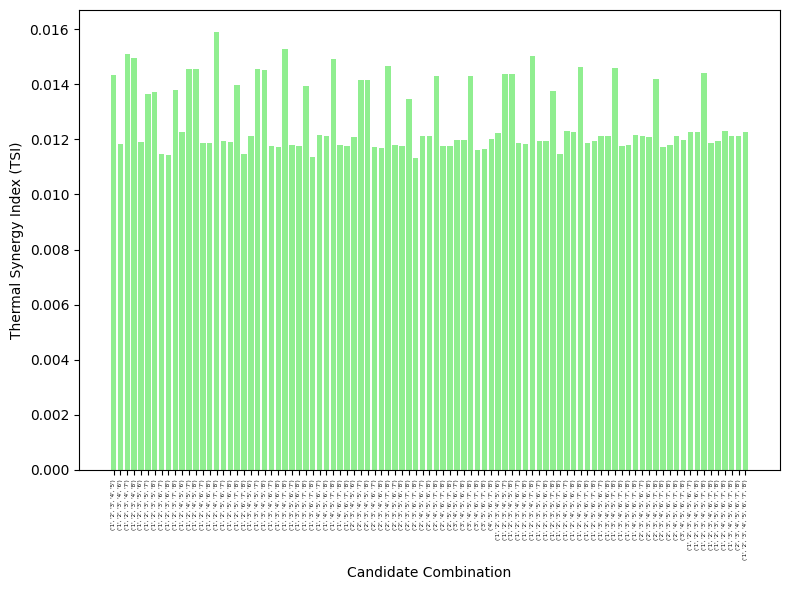

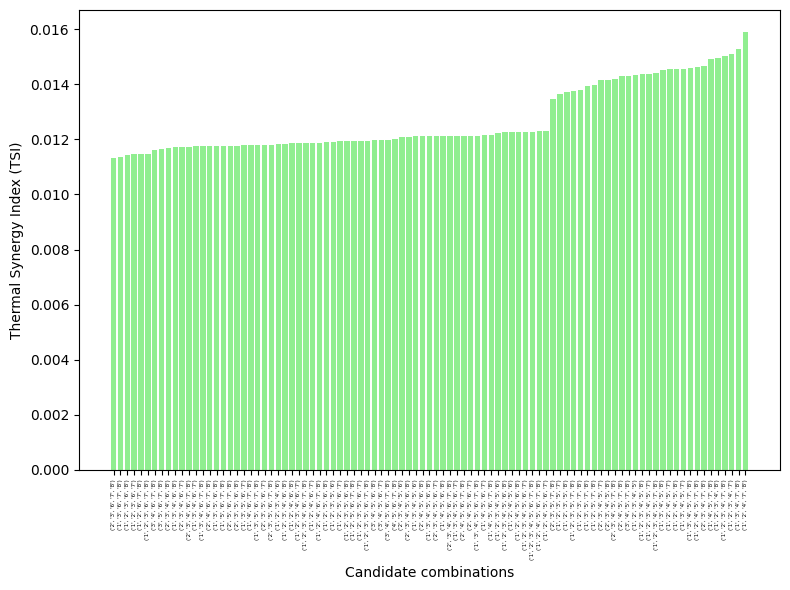

In [10]:
# Plot TSI for all combinations as a bar graph.
tsi_values = [combination_results_TSI[combo] for combo in combos]

plt.figure(figsize=(8, 6))
plt.bar(range(len(combos)), tsi_values, color='lightgreen')
plt.xlabel("Candidate Combination")
plt.ylabel("Thermal Synergy Index (TSI)")
plt.xticks(range(len(combos)), [str(combo) for combo in combos], rotation=90, fontsize=4)
plt.tight_layout()
plt.show()

# Sort combinations by increasing standard deviation
sorted_combos = sorted(combination_results_TSI.items(), key=lambda x: x[1])
sorted_labels = [str(combo[0]) for combo in sorted_combos]
sorted_values = [combo[1] for combo in sorted_combos]

# Plot ordered bar graph
plt.figure(figsize=(8, 6))
plt.bar(range(len(sorted_labels)), sorted_values, color='lightgreen')
plt.xlabel("Candidate combinations")
plt.ylabel("Thermal Synergy Index (TSI)")
#plt.title("Evaluation of candidate combinations (Sorted by Performance)")
plt.xticks(range(len(sorted_labels)), sorted_labels, rotation=90, fontsize=4)
plt.tight_layout()
plt.show()

**Plot 3a: Variation of TS by group size (line plot)**

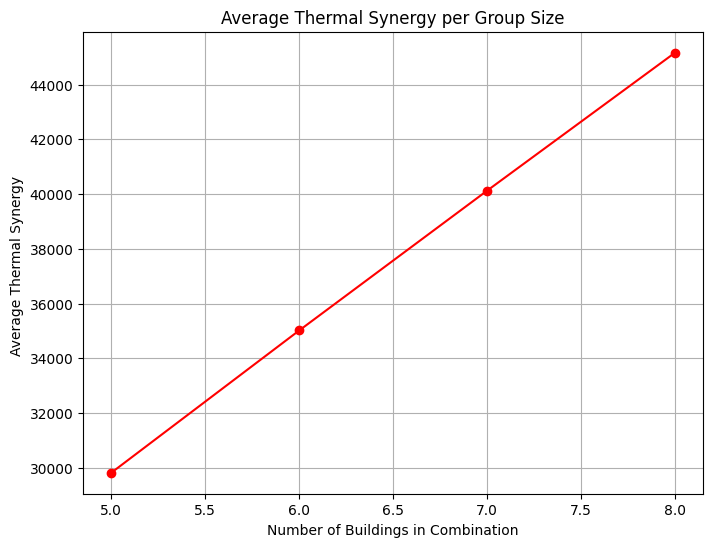

In [11]:
# =======================================================
# **PLOT AVERAGE TS PER GROUP SIZE**
# =======================================================
plt.figure(figsize=(8, 6))
plt.plot(list(size_group_ts.keys()), list(size_group_ts.values()), marker='o', linestyle='-', color='red')
plt.xlabel("Number of Buildings in Combination")
plt.ylabel("Average Thermal Synergy ")
plt.title("Average Thermal Synergy per Group Size")
plt.grid(True)
plt.show()

**Plot 3b: Variation of TS by group size (box plot)**

C:\Users\matteo.bilardo\AppData\Local\Temp\ipykernel_18812\64472343.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=list(size_group_ts.keys()))


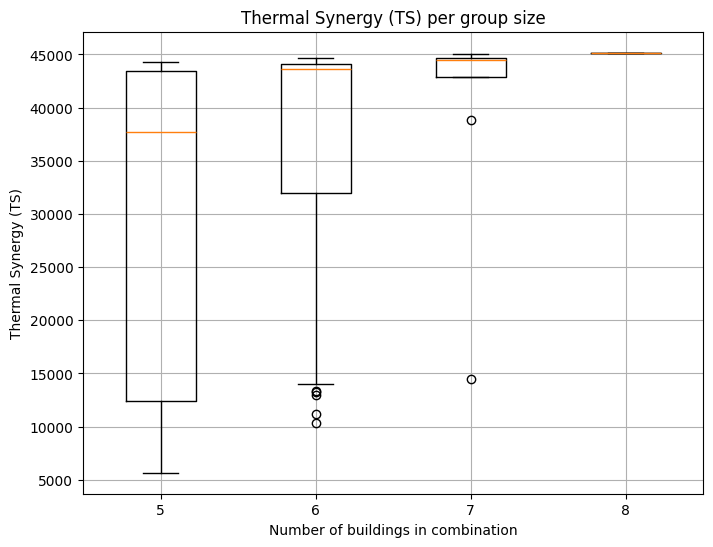

C:\Users\matteo.bilardo\AppData\Local\Temp\ipykernel_18812\64472343.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, positions=group_sizes_box, widths=0.6, patch_artist=False, labels=group_sizes_box)


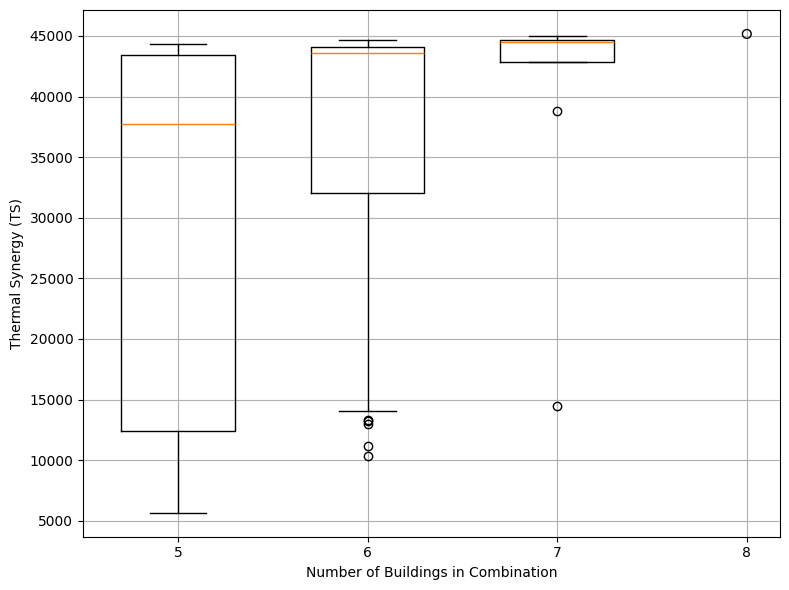

In [12]:
# Version1 
# BOX PLOT TS PER GROUP SIZE

plt.figure(figsize=(8, 6))
boxplot_data = [
    [combination_results[combo] for combo in combination_results if len(combo) == group_size]
    for group_size in size_group_ts.keys()
]
plt.boxplot(boxplot_data, labels=list(size_group_ts.keys()))
plt.xlabel("Number of buildings in combination")
plt.ylabel("Thermal Synergy (TS)")
plt.title("Thermal Synergy (TS) per group size")
plt.grid(True)
plt.show()

# Version2
# BOX PLOT TS PER GROUP SIZE WITH SINGLE-POINT OVERLAY

plt.figure(figsize=(8, 6))

# Prepare lists for group sizes with >1 data point and with exactly one data point.
group_sizes_box = []
boxplot_data = []
group_sizes_single = []
single_values = []

for group_size in sorted(size_group_ts.keys()):
    data = [combination_results[combo] for combo in combination_results if len(combo) == group_size]
    if len(data) > 1:
        group_sizes_box.append(group_size)
        boxplot_data.append(data)
    elif len(data) == 1:
        group_sizes_single.append(group_size)
        single_values.append(data[0])

# Plot boxplots for group sizes with more than one data point.
if boxplot_data:
    plt.boxplot(boxplot_data, positions=group_sizes_box, widths=0.6, patch_artist=False, labels=group_sizes_box)

# Overlay scatter markers (circles) for group sizes with a single data point.
if group_sizes_single:
    plt.scatter(group_sizes_single, single_values, color='None', edgecolors='black', s=40, marker='o', zorder=3, label='All buildings Combination')

# Ensure x-tick labels include all group sizes.
xtick_positions = sorted(set(group_sizes_box).union(set(group_sizes_single)))
plt.xticks(xtick_positions, labels=[str(x) for x in xtick_positions])

plt.xlabel("Number of Buildings in Combination")
plt.ylabel("Thermal Synergy (TS)")
#plt.title("Thermal Synergy per Group Size")
plt.grid(True)
#plt.legend()
plt.tight_layout()
plt.show()




**PLot 4: Correlation between TS and TSI**

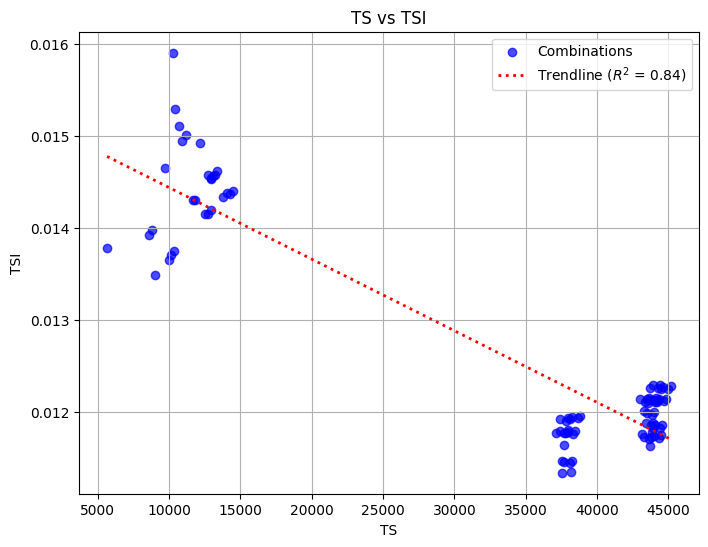

In [13]:
# Extract values from the computed results
x_values = [combination_results[combo] for combo in combos]  # X-axis: first computed metric
y_values = [combination_results_TSI[combo] for combo in combos]  # Y-axis: second computed metric

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x_values, y_values, color='blue', alpha=0.7, label="Combinations")

# Compute and plot the trendline
slope, intercept, r_value, p_value, std_err = linregress(x_values, y_values) 
x_trend = np.linspace(min(x_values), max(x_values), 100)
y_trend = slope * x_trend + intercept

# Stampa la linea di tendenza e il valore di R^2
plt.plot(x_trend, y_trend, color='red', linewidth=2, linestyle=':', label=f"Trendline ($R^2$ = {r_value**2:.2f})".format(r_value=r_value))

# Add labels and title
plt.xlabel("TS")
plt.ylabel("TSI")
plt.title("TS vs TSI")
plt.legend()
plt.grid(True)

# Show plot
plt.show()

**Plot 5: Correlation between TS and eta_th**

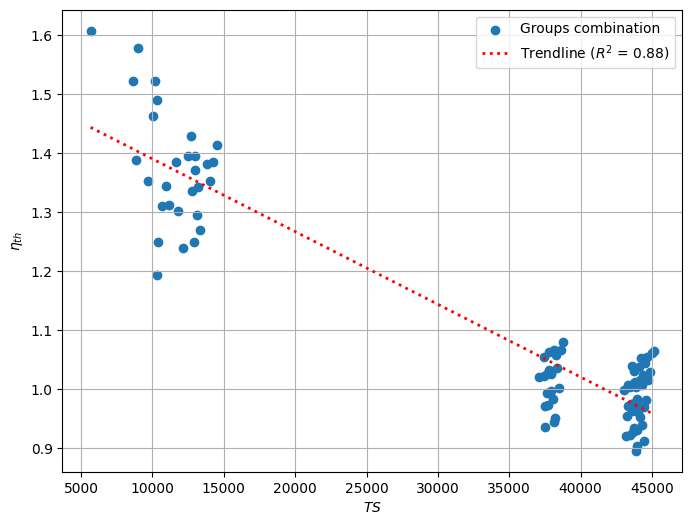

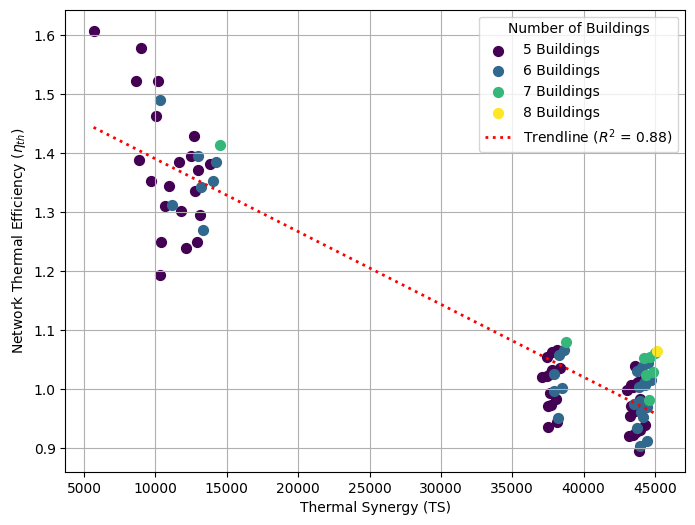

In [14]:
#This script read the output file from the 5GDHC simulation, where the eta_th values was simulated in each 5GDHC scenario identified.
#The file "simRes" was manually created retriving data form both TS/TSI evaluation and 5GDHC detailed simulation

# ------------------------------------------------------------#
#Version 1: no specification about group size
# ------------------------------------------------------------#

# Read the Excel file
try:
    df = pd.read_excel("simRes.xlsx")  # 5GDHC custom simulation file output
except FileNotFoundError:
    print("Error: Excel file not found.")
    exit()

# Extract required columns
try:
    x = df['TS']  # Select first variable to study correlation (TS in the BS paper case)
    y = df['eta_th']  # Select second variable to study correlation (eta_th in the BS paper case)
except KeyError as e:
    print(f"Error: Column '{e}' not found in the Excel file.")
    exit()

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label="Groups combination") 

# Compute and plot the trendline and R^2
slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_new = np.linspace(x.min(), x.max(), 50) 
line = slope * x_new + intercept 
plt.plot(x_new, line, color='red', linewidth=2, linestyle=':', label=f"Trendline ($R^2$ = {r_value**2:.2f})".format(r_value=r_value))

# Add labels, title and legend
plt.xlabel("$TS$") 
plt.ylabel(r"$\eta_{th}$") 
#plt.title(r"Network thermal efficiency ($\eta_{th}$) vs $TS$")

plt.legend()

# Show plot
plt.grid(True)  # Plot grid
plt.show()

# ------------------------------------------------------------#
#Version 2: with  specification about group size (color code)
# ------------------------------------------------------------#

# Read the Excel file
try:
    df = pd.read_excel("simRes.xlsx")
except FileNotFoundError:
    print("Error: Excel file not found.")
    exit()

# Extract required columns
try:
    x = df['TS']    # Select first variable to study correlation (TS in the BS paper case)
    y = df['eta_th']  # Select second variable to study correlation (eta_th in the BS paper case)
    combo_str = df['combination'] 
except KeyError as e:
    print(f"Error: Column '{e}' not found in the Excel file.")
    exit()

# Create a new column for the number of buildings by counting items in the combination string
df['num_buildings'] = combo_str.apply(lambda s: len([item.strip() for item in s.split(',') if item.strip()]))

# Define unique building group sizes and assign discrete colors
unique_nums = sorted(df['num_buildings'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_nums)))  # Generate distinct colors

# Create scatter plot
plt.figure(figsize=(8, 6))

# Plot each group size separately to ensure proper legend handling
scatter_handles = []
for num, color in zip(unique_nums, colors):
    subset = df[df['num_buildings'] == num]
    sc = plt.scatter(subset['TS'], subset['eta_th'], color=color, label=f"{num} Buildings", s=50)
    scatter_handles.append(sc)  # Store handle for legend

# Compute and plot the trendline
slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_new = np.linspace(x.min(), x.max(), 50)
line = slope * x_new + intercept
trendline, = plt.plot(x_new, line, color='red', linewidth=2, linestyle=':',
         label=f"Trendline ($R^2$ = {r_value**2:.2f})")

# Add labels, title and legend
plt.xlabel("Thermal Synergy (TS)")
plt.ylabel(r"Network Thermal Efficiency ($\eta_{th}$)")
#plt.title("Network Thermal Efficiency vs TS")
plt.grid(True)
plt.legend(handles=scatter_handles + [trendline], title="Number of Buildings")

plt.show()

**Plot 6: Correlation between TS vs I_int**

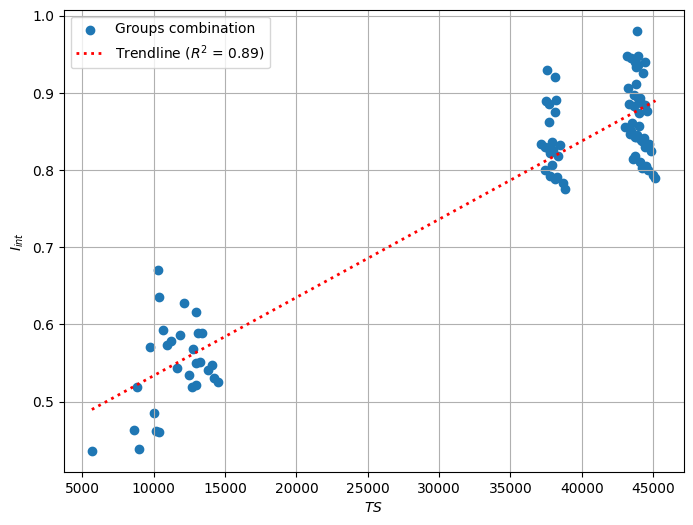

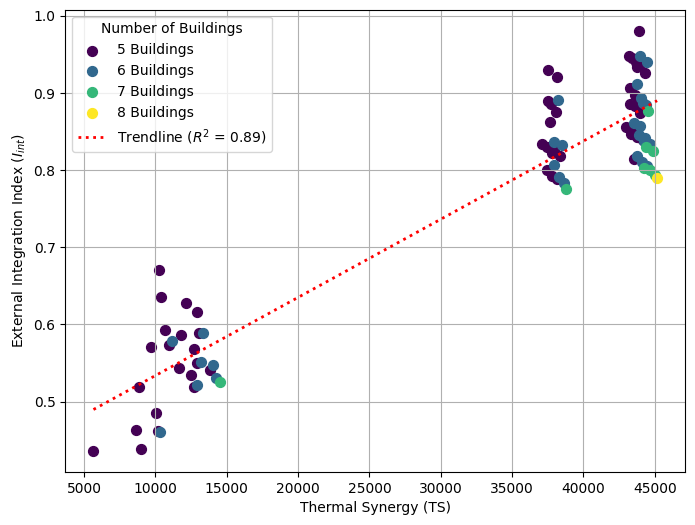

In [15]:
#This script read the output file from the 5GDHC simulation, where the eii values was simulated in each 5GDHC scenario identified.
#The file "simRes" was manually created retriving data form both TS/TSI evaluation and 5GDHC detailed simulation

# ------------------------------------------------------------#
#Version 1: no specification about group size
# ------------------------------------------------------------#

# Read Excel file
try:
    df = pd.read_excel("simRes.xlsx")   # 5GDHC custom simulation file output
except FileNotFoundError:
    print("Errore: File Excel non trovato.")
    exit()

# Extract required columns
try:
    x = df['TS']  # Select first variable to study correlation (TS in the BS paper case)
    y = df['eii']  # Select second variable to study correlation (eii in the BS paper case)
except KeyError as e:
    print(f"Errore: Colonna '{e}' non trovata nel file Excel.")
    exit()

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label="Groups combination")

# Compute and plot the trendline
slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_new = np.linspace(x.min(), x.max(), 50) 
line = slope * x_new + intercept
plt.plot(x_new, line, color='red', linewidth=2, linestyle=':', label=f"Trendline ($R^2$ = {r_value**2:.2f})".format(r_value=r_value))

# Add labels, title and legend
plt.xlabel("$TS$") 
plt.ylabel(r"$I_{int}$") 
#plt.title(r"Network external integration index ($I_{int}$) vs $TS$")
plt.legend()

plt.grid(True)  # Plot grid
plt.show()



# ------------------------------------------------------------#
#Version 2: with  specification about group size (color code)
# ------------------------------------------------------------#

# Read the Excel file
try:
    df = pd.read_excel("simRes.xlsx")
except FileNotFoundError:
    print("Error: Excel file not found.")
    exit()

# Extract required columns
try:
    x = df['TS']  # Select first variable to study correlation (TS in the BS paper case)
    y = df['eii']  # Select second variable to study correlation (eii in the BS paper case)
    combo_str = df['combination'] 
except KeyError as e:
    print(f"Error: Column '{e}' not found in the Excel file.")
    exit()

# Create a new column for the number of buildings by counting items in the combination string
df['num_buildings'] = combo_str.apply(lambda s: len([item.strip() for item in s.split(',') if item.strip()]))

# Define unique building group sizes and assign discrete colors
unique_nums = sorted(df['num_buildings'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_nums)))  # Generate distinct colors

# Create scatter plot
plt.figure(figsize=(8, 6))

# Plot each group size separately to ensure proper legend handling
scatter_handles = []
for num, color in zip(unique_nums, colors):
    subset = df[df['num_buildings'] == num]
    sc = plt.scatter(subset['TS'], subset['eii'], color=color, label=f"{num} Buildings", s=50)
    scatter_handles.append(sc)  # Store handle for legend

# Compute and plot the trendline
slope, intercept, r_value, p_value, std_err = linregress(x, y)
x_new = np.linspace(x.min(), x.max(), 50)
line = slope * x_new + intercept
trendline, = plt.plot(x_new, line, color='red', linewidth=2, linestyle=':',
         label=f"Trendline ($R^2$ = {r_value**2:.2f})")

# Add labels, title and legend
plt.xlabel("Thermal Synergy (TS)")
plt.ylabel(r"External Integration Index ($I_{int}$)")
#plt.title("External Integration Index vs TS")
plt.grid(True)
plt.legend(handles=scatter_handles + [trendline], title="Number of Buildings")

plt.show()

**Plot 7: Buildings correlation matrix**

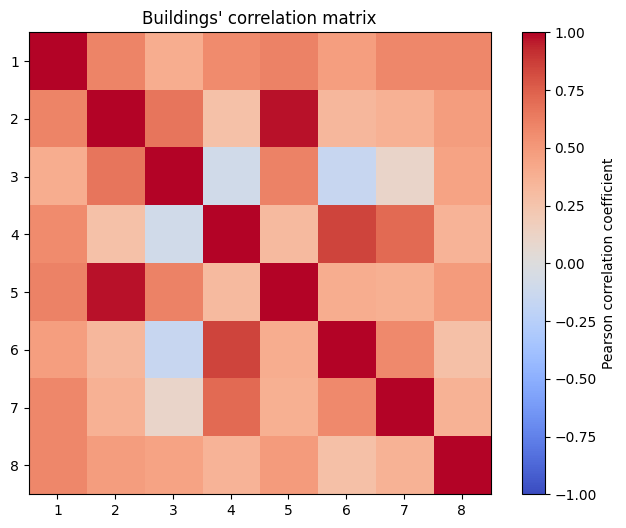

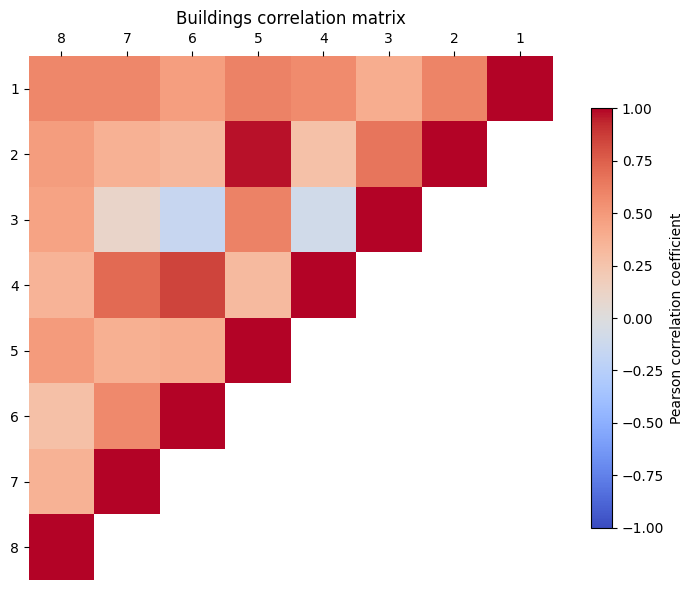

In [16]:
# Computing the building correlation matrix, based on the Pearson correlation coefficient evaluated for each building pair present in the dataset

# ------------------------------------------------------------#
#Version 1: full matrix representation
# ------------------------------------------------------------#

correlation_matrix = np.zeros((len(buildings), len(buildings))) 
building_names = list(buildings.keys()) 

for i, building1_name in enumerate(building_names):
    for j, building2_name in enumerate(building_names):
        correlation = np.corrcoef(buildings[building1_name]['base'], buildings[building2_name]['base'])[0, 1] #Pearson correlation coefficinet computation
        correlation_matrix[i, j] = correlation

# Plotting correlation matrix
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Pearson correlation coefficient")  
plt.xticks(np.arange(len(building_names)), labels=building_names)
plt.yticks(np.arange(len(building_names)), labels=building_names)
plt.title("Buildings' correlation matrix")
plt.show()

# ------------------------------------------------------------#
#Version 2: half matrix representation
# ------------------------------------------------------------#

# Masking lower section of the correlation matrix
mask = np.zeros_like(correlation_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

# Rotate matrix and axis labels
rotated_matrix = np.rot90(correlation_matrix, k=3)
rotated_names = building_names[::-1]

plt.figure(figsize=(8, 6))

# Apply the mask if necessary
if 'mask' in locals():
    masked_matrix = np.ma.masked_array(rotated_matrix, mask=np.rot90(mask, k=3))
    image = plt.imshow(masked_matrix, cmap="coolwarm", vmin=-1, vmax=1)
else:
    image = plt.imshow(rotated_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Remove the outline of the graph.
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

# Add color bar
cbar = plt.colorbar(image, label="Pearson correlation coefficient", shrink=0.8)

# Place x-axis labels on top.
plt.xticks(np.arange(len(rotated_names)), labels=rotated_names)
plt.yticks(np.arange(len(rotated_names)), labels=rotated_names[::-1])
plt.gca().xaxis.tick_top()  # Move labels up
plt.gca().xaxis.set_label_position('top') #Move the x-axis label to the top

plt.title("Buildings correlation matrix")

plt.tight_layout()
plt.show()


**Data saving**

In [17]:

# This script saves in a .csv the TS and TSI values of each building combination

# Define the CSV filename
output_filename = "combination_results.csv"

# Open the file and write the header + data
with open(output_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    
    # Write header
    writer.writerow(["Combination Group", "TS Value", "TSI Value"])
    
    # Write data
    for combo in combination_results_TSI.keys():
        writer.writerow([", ".join(map(str, combo)),combination_results[combo], combination_results_TSI[combo]])

print(f"CSV file '{output_filename}' has been successfully created.")


CSV file 'combination_results.csv' has been successfully created.
